# Information
This notebook is an extension of the report "Training a CNN Classifier on the CIFAR-10 Dataset" by Marcus Persson (S5343798), Emily Heugen (S5587042), and Richard Harnisch (S5238366). This notebook outlines our motivations behind training our models and codework.

# Dependencies
A note about ResNet18: We utilised an external collection of classificiation models, as Tensorflow only contained ResNet50. So, we had to install the dependcy via `pip`.

In [ ]:
!pip install git+https://github.com/qubvel/classification_models.git

import tensorflow as tf
from tensorflow import keras as k
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix
from tabulate import tabulate
from classification_models.tfkeras import Classifiers

  Cloning https://github.com/qubvel/classification_models.git to /tmp/pip-req-build-nay_2te7
  Running command git clone --filter=blob:none --quiet https://github.com/qubvel/classification_models.git /tmp/pip-req-build-nay_2te7
  Resolved https://github.com/qubvel/classification_models.git to commit a0f006e05485a34ccf871c421279864b0ccd220b
  Running command git submodule update --init --recursive -q
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.7/50.7 kB 3.1 MB/s eta 0:00:00
  Created wheel for image_classifiers: filename=image_classifiers-1.0.0-py3-none-any.whl size=20029 sha256=a9b4592b2b185b88c0cc0d387e8bdf7b6d29326f59df4f964b16be9fbe07a208
  Stored in directory: /tmp/pip-ephem-wheel-cache-b80t504q/wheels/14/43/ed/2d68b197c5260e7fe6b7d0fab20b997b6d365f6f5732316952
Successfully built image_classifiers


# Data handling and preprocessing
The CIFAR-10 dataset is included in the Tensorflow library, so we can load it directly and begin assigning variables to our training and testing datasets. We normalise our pixel values to ensure numerical stability and speed up model convergence. Furthermore, CNNs and ResNet18 benefit from a smaller range of inputs. Finally, we flatten our labels to standardise our classsification tasks.

In [ ]:
cifar10 = k.datasets.cifar10
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0
y_train, y_test = y_train.flatten(), y_test.flatten()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step


A unique direction we took was augmenting our data to diversify our imageset. We knew that similar projects training on the CIFAR-10 imageset were done in the past, so we wanted to observe if the models would still perform well on augmented images, while still generalising well and not overfitting.

In [ ]:
data_augmentation = k.Sequential([
    k.layers.RandomFlip("horizontal"),  # Random horizontal flip
    k.layers.RandomRotation(0.1),      # Random rotation
    k.layers.RandomZoom(0.1),          # Random zoom
])

To align with standard practice and balance computational effiency, our batch size is 32. Only our training dataset included the augmented images, as to avoid overfitting if we were too include the augmented imagset in our testing dataset. Furthermore, we shuffle the imageset to prevent the models from memorizing the order of samples, as to ensure better generalisation.

In [ ]:
batch_size = 32
train_dataset = (tf.data.Dataset.from_tensor_slices((x_train, y_train))
                .map(lambda x, y: (data_augmentation(x, training=True), y))
                .shuffle(buffer_size=10000)
                .batch(batch_size)
                .prefetch(tf.data.AUTOTUNE)
)
test_dataset = (tf.data.Dataset.from_tensor_slices((x_test, y_test))
                .batch(batch_size)
                .prefetch(tf.data.AUTOTUNE)
)

Here is the non-augmented dataset plotted.

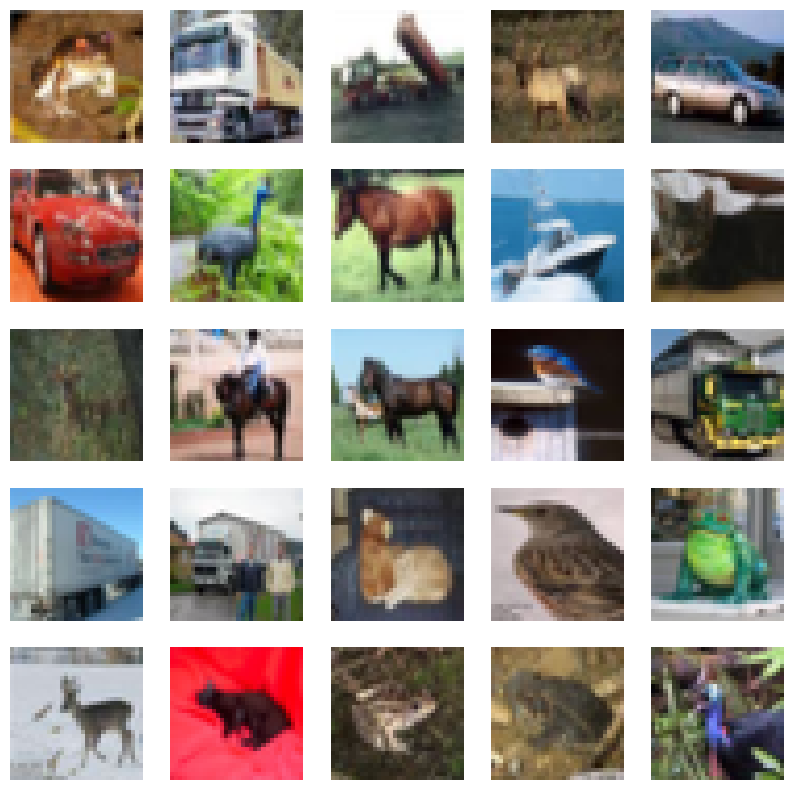

In [ ]:
# Display some of the original training data
fig, ax = plt.subplots(5, 5, figsize=(10, 10))
for i, img in enumerate(x_train[:25]):
    ax[i // 5, i % 5].imshow(img)
    ax[i // 5, i % 5].axis("off")

plt.show()

Here is the augmented dataset plotted.

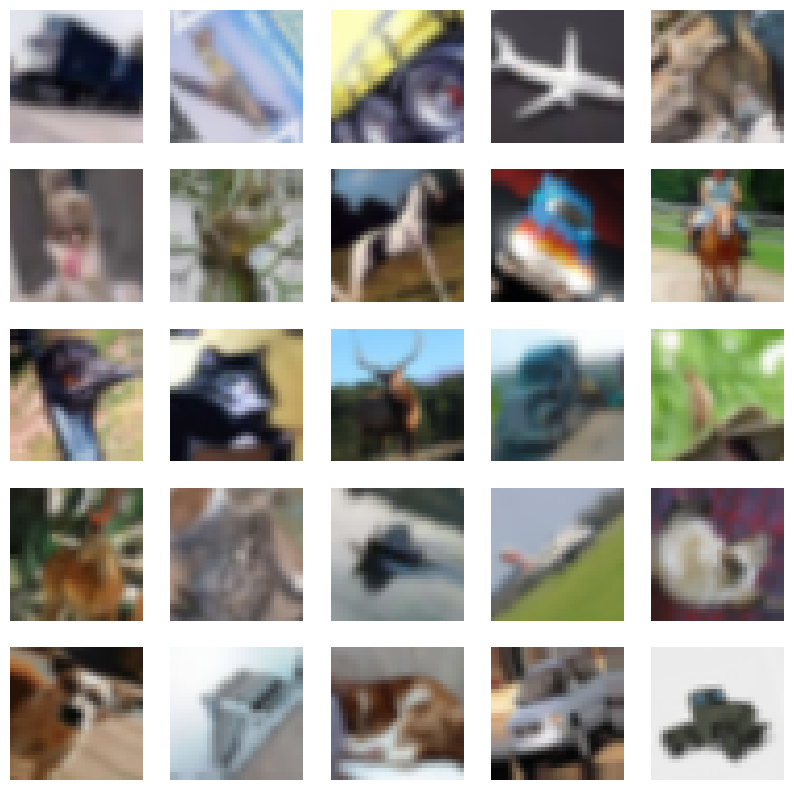

In [ ]:
fig, ax = plt.subplots(5, 5, figsize=(10, 10))
for i, (img, _) in enumerate(train_dataset.take(25)):
    augmented_img = tf.map_fn(lambda x: data_augmentation(x, training=True), img)
    ax[i // 5, i % 5].imshow(augmented_img[0].numpy())
    ax[i // 5, i % 5].axis("off")

plt.show()

# Training and evaluation of the custom CNN model
The custom CNN consists of three convolutional layers, each followed by batch normalization, ReLU activation, and max pooling. The feature maps are flattened and passed through two fully connected layers, with dropout regularization applied before the final softmax output.

In [ ]:
model = k.models.Sequential([
    k.layers.Input(shape=(32, 32, 3)),
    k.layers.Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal'),
    k.layers.BatchNormalization(),
    k.layers.MaxPooling2D((2, 2)),
    k.layers.Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal'),
    k.layers.BatchNormalization(),
    k.layers.MaxPooling2D((2, 2)),
    k.layers.Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal'),
    k.layers.BatchNormalization(),
    k.layers.Flatten(),
    k.layers.Dropout(0.5),
    k.layers.Dense(128, activation='relu', kernel_initializer='he_normal'),
    k.layers.Dense(10, activation='softmax')
])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)                    │ (None, 30, 30, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 30, 30, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 15, 15, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 13, 13, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 13, 13, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 6, 6, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 4, 4, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 4, 4, 128)           │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │         262,272 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 357,706 (1.36 MB)

 Trainable params: 357,258 (1.36 MB)

 Non-trainable params: 448 (1.75 KB)

We compile our CNN with the Adam optimizer (with a learning rate of 0.001) to balance fast convergence and stability. Additionly, we use the Sparse Categorical Crossentropy as it is ideal for multi-class classification with integer-labeled targets. We use accuracy as the primary performance metric. The model is trained for 20 epochs with a batch size of 32, to strike a balance between computational efficiency and gradient updates.

In [ ]:
model.compile(
    optimizer=k.optimizers.Adam(learning_rate=0.001),
    loss=k.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

epochs=20

history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=epochs,
    batch_size=batch_size,
)

Epoch 1/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 61s 31ms/step - accuracy: 0.3673 - loss: 1.9760 - val_accuracy: 0.4873 - val_loss: 1.4637
Epoch 2/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 52s 28ms/step - accuracy: 0.5162 - loss: 1.3661 - val_accuracy: 0.5963 - val_loss: 1.1428
Epoch 3/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 70s 34ms/step - accuracy: 0.5611 - loss: 1.2368 - val_accuracy: 0.6191 - val_loss: 1.0777
Epoch 4/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 55s 30ms/step - accuracy: 0.5896 - loss: 1.1618 - val_accuracy: 0.6259 - val_loss: 1.0595
Epoch 5/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 53s 28ms/step - accuracy: 0.6095 - loss: 1.1118 - val_accuracy: 0.6302 - val_loss: 1.0445
Epoch 6/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 54s 29ms/step - accuracy: 0.6269 - loss: 1.0505 - val_accuracy: 0.6775 - val_loss: 0.9301
Epoch 7/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 53s 28ms/step - accuracy: 0.6418 - loss: 1.0219 - val_accuracy: 0.6452 - val_loss: 1.0349
Epoch 8/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 29ms/step - accuracy: 0.6576 -

We plot the CNN model and write the results.

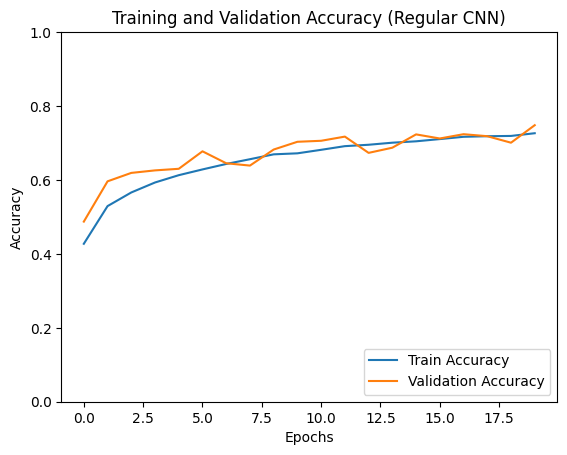

In [ ]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy (Regular CNN)')
plt.show()

In [ ]:
test_loss, test_acc = model.evaluate(test_dataset, verbose=2)

print(f"Test Accuracy:\n{test_acc:.4f}")
print(f"Test Loss:\n{test_loss:.4f}")

true_labels = np.concatenate([batch_labels for _, batch_labels in test_dataset])
predictions = np.argmax(model.predict(test_dataset), axis=1)
conf_matrix = confusion_matrix(true_labels, predictions)

print(f"Confusion Matrix:\n{conf_matrix}")

precision = np.diag(conf_matrix) / np.sum(conf_matrix, axis=0)
recall = np.diag(conf_matrix) / np.sum(conf_matrix, axis=1)
f1_score = 2 * (precision * recall) / (precision + recall)

print(f"\nPrecision per class:\n{np.array2string(np.nan_to_num(precision), formatter={'float_kind': lambda x: f'{x:.4f}'})}")
print(f"Recall per class:\n{np.array2string(np.nan_to_num(recall), formatter={'float_kind': lambda x: f'{x:.4f}'})}")
print(f"F1-score per class:\n{np.array2string(np.nan_to_num(f1_score), formatter={'float_kind': lambda x: f'{x:.4f}'})}")

313/313 - 1s - 2ms/step - accuracy: 0.7482 - loss: 0.7211
Test Accuracy:
0.7482
Test Loss:
0.7211
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Confusion Matrix:
[[779  36  24  20   2   4   4   9  62  60]
 [  6 911   2   7   0   4   4   3  10  53]
 [ 75  17 609  73  43  49  73  21  17  23]
 [ 20  11  42 616  40 134  59  24  15  39]
 [ 29   4  48  73 652  31  79  53  13  18]
 [ 15  10  25 179  34 640  38  30   4  25]
 [  5  12  21  67  10   5 850   2   8  20]
 [ 24   9  19  41  36  54  22 748   2  45]
 [ 66  38  11  14   1   5   4   1 824  36]
 [ 14  89   6   7   0   6   7   3  15 853]]

Precision per class:
[0.7541 0.8012 0.7546 0.5615 0.7971 0.6867 0.7456 0.8367 0.8495 0.7278]
Recall per class:
[0.7790 0.9110 0.6090 0.6160 0.6520 0.6400 0.8500 0.7480 0.8240 0.8530]
F1-score per class:
[0.7664 0.8526 0.6740 0.5875 0.7173 0.6625 0.7944 0.7899 0.8365 0.7855]


# Training and evaluation of the ResNet18 model
The base layers of ResNet18 remain frozen to retain learned feature representations, while a new classification head is trained for CIFAR-10. The classification head consists of a global average pooling layer, a dense layer (128 neurons, ReLU activation), and a final softmax layer. The training follows the same supervised learning process, but only the newly added layers are updated.

In [ ]:
ResNet18, preprocess_input = Classifiers.get('resnet18')

resnet18_model = ResNet18(
    include_top=False,
    weights="imagenet",
    input_shape=(32, 32, 3)
)

resnet18_model.trainable = False

finetuned_model = k.models.Sequential([
    resnet18_model,
    k.layers.GlobalAveragePooling2D(),
    k.layers.Dense(128, activation="relu", kernel_initializer="he_normal"),
    k.layers.Dense(10, activation="softmax")
])

finetuned_model.summary()

44920640/44920640 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ functional_3 (Functional)            │ (None, 1, 1, 512)           │      11,186,889 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 512)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 128)                 │          65,664 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,253,843 (42.93 MB)

 Trainable params: 66,954 (261.54 KB)

 Non-trainable params: 11,186,889 (42.67 MB)

We compile and fit our ResNet18 model under the same conditions had for the CNN model.

In [ ]:
finetuned_model.compile(optimizer=k.optimizers.Adam(learning_rate=0.001),
                        loss=k.losses.SparseCategoricalCrossentropy(),
                        metrics=['accuracy'])

finetuned_history = finetuned_model.fit(train_dataset,
                                        validation_data=test_dataset,
                                        epochs=epochs,
                                        batch_size=batch_size)

Epoch 1/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 65s 33ms/step - accuracy: 0.1088 - loss: 2.3054 - val_accuracy: 0.1056 - val_loss: 2.2861
Epoch 2/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 77s 31ms/step - accuracy: 0.1437 - loss: 2.2682 - val_accuracy: 0.1381 - val_loss: 2.2588
Epoch 3/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 57s 31ms/step - accuracy: 0.1579 - loss: 2.2240 - val_accuracy: 0.1523 - val_loss: 2.2333
Epoch 4/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 55s 29ms/step - accuracy: 0.1645 - loss: 2.2067 - val_accuracy: 0.1514 - val_loss: 2.2630
Epoch 5/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 55s 29ms/step - accuracy: 0.1648 - loss: 2.2018 - val_accuracy: 0.1677 - val_loss: 2.2107
Epoch 6/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 29ms/step - accuracy: 0.1685 - loss: 2.1925 - val_accuracy: 0.1667 - val_loss: 2.2179
Epoch 7/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 55s 29ms/step - accuracy: 0.1729 - loss: 2.1839 - val_accuracy: 0.1790 - val_loss: 2.2042
Epoch 8/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 57s 30ms/step - accuracy: 0.1780 -

We plot the ResNet18 model and write the results.



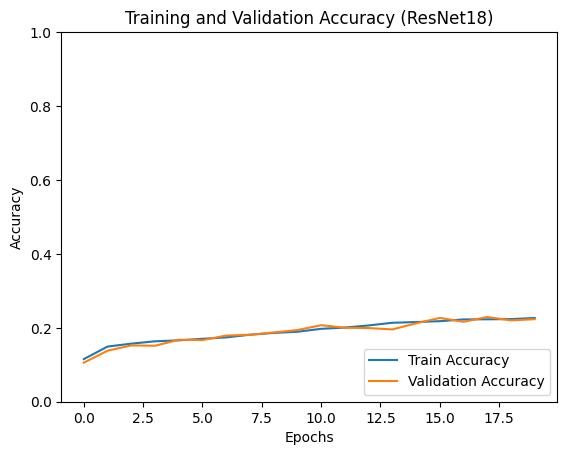

In [ ]:
plt.plot(finetuned_history.history['accuracy'], label='Train Accuracy')
plt.plot(finetuned_history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy (ResNet18)')
plt.show()

In [ ]:
finetuned_loss, finetuned_acc = finetuned_model.evaluate(test_dataset, verbose=2)

print(f"Fine-Tuned Model Accuracy:\n{finetuned_acc:.4f}")
print(f"Fine-Tuned Model Loss:\n{finetuned_loss:.4f}")

true_labels = np.concatenate([batch_labels for _, batch_labels in test_dataset])
finetuned_predictions = np.argmax(finetuned_model.predict(test_dataset), axis=1)
finetuned_conf_matrix = confusion_matrix(true_labels, finetuned_predictions)

print(f"Fine-Tuned Confusion Matrix:\n{finetuned_conf_matrix}")

finetuned_precision = np.diag(finetuned_conf_matrix) / np.sum(finetuned_conf_matrix, axis=0)
finetuned_recall = np.diag(finetuned_conf_matrix) / np.sum(finetuned_conf_matrix, axis=1)
finetuned_f1_score = 2 * (finetuned_precision * finetuned_recall) / (finetuned_precision + finetuned_recall)

print(f"\nPrecision per class:\n{np.array2string(np.nan_to_num(finetuned_precision), formatter={'float_kind': lambda x: f'{x:.4f}'})}")
print(f"Recall per class:\n{np.array2string(np.nan_to_num(finetuned_recall), formatter={'float_kind': lambda x: f'{x:.4f}'})}")
print(f"F1-score per class:\n{np.array2string(np.nan_to_num(finetuned_f1_score), formatter={'float_kind': lambda x: f'{x:.4f}'})}")

313/313 - 1s - 4ms/step - accuracy: 0.2233 - loss: 2.0987
Fine-Tuned Model Accuracy:
0.2233
Fine-Tuned Model Loss:
2.0987
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step
Fine-Tuned Confusion Matrix:
[[  9 299   1   3 110  92  33  46 240 167]
 [  0 534   0   1   2 122  10  59  20 252]
 [  4 159   0   9 199 354  35 103  78  59]
 [  4 185   1  18  76 428  29 142  27  90]
 [  1 162   2  12 194 362  60  87  63  57]
 [  1 166   1  11  60 537  24 129  33  38]
 [  2 286   4   8  45 367  35 148  30  75]
 [  6 322   2   3  31 309  16 136  20 155]
 [  8 315   2   1  37 101  17  15 354 150]
 [  2 406   2   5   4  55  13  68  29 416]]

Precision per class:
[0.2432 0.1884 0.0000 0.2535 0.2559 0.1969 0.1287 0.1458 0.3960 0.2851]
Recall per class:
[0.0090 0.5340 0.0000 0.0180 0.1940 0.5370 0.0350 0.1360 0.3540 0.4160]
F1-score per class:
[0.0174 0.2786 0.0000 0.0336 0.2207 0.2882 0.0550 0.1407 0.3738 0.3383]


<ipython-input-17-fee26316f23f>:15: RuntimeWarning: invalid value encountered in divide
  finetuned_f1_score = 2 * (finetuned_precision * finetuned_recall) / (finetuned_precision + finetuned_recall)


# Final Comparisons

In [ ]:
print(f'CNN Confusion Matrix:\n{conf_matrix}')
print(f'ResNet18 Confusion Matrix:\n{finetuned_conf_matrix}')

print('\n' + tabulate([
    ['Accuracy', f'{test_acc:.4f}', f'{finetuned_acc:.4f}'],
    ['Loss', f'{test_loss:.4f}', f'{finetuned_loss:.4f}'],
    ['Precision', np.array2string(np.nan_to_num(precision), formatter={'float_kind': lambda x: f'{x:.4f}'}), np.array2string(np.nan_to_num(finetuned_precision), formatter={'float_kind': lambda x: f'{x:.4f}'})],
    ['Recall', np.array2string(np.nan_to_num(recall), formatter={'float_kind': lambda x: f'{x:.4f}'}), np.array2string(np.nan_to_num(finetuned_recall), formatter={'float_kind': lambda x: f'{x:.4f}'})],
    ['F1-Score', np.array2string(np.nan_to_num(f1_score), formatter={'float_kind': lambda x: f'{x:.4f}'}), np.array2string(np.nan_to_num(finetuned_f1_score), formatter={'float_kind': lambda x: f'{x:.4f}'})]],
    headers=['', 'CNN', 'ResNet18'], tablefmt='orgtbl'))

CNN Confusion Matrix:
[[779  36  24  20   2   4   4   9  62  60]
 [  6 911   2   7   0   4   4   3  10  53]
 [ 75  17 609  73  43  49  73  21  17  23]
 [ 20  11  42 616  40 134  59  24  15  39]
 [ 29   4  48  73 652  31  79  53  13  18]
 [ 15  10  25 179  34 640  38  30   4  25]
 [  5  12  21  67  10   5 850   2   8  20]
 [ 24   9  19  41  36  54  22 748   2  45]
 [ 66  38  11  14   1   5   4   1 824  36]
 [ 14  89   6   7   0   6   7   3  15 853]]
ResNet18 Confusion Matrix:
[[  9 299   1   3 110  92  33  46 240 167]
 [  0 534   0   1   2 122  10  59  20 252]
 [  4 159   0   9 199 354  35 103  78  59]
 [  4 185   1  18  76 428  29 142  27  90]
 [  1 162   2  12 194 362  60  87  63  57]
 [  1 166   1  11  60 537  24 129  33  38]
 [  2 286   4   8  45 367  35 148  30  75]
 [  6 322   2   3  31 309  16 136  20 155]
 [  8 315   2   1  37 101  17  15 354 150]
 [  2 406   2   5   4  55  13  68  29 416]]

|           | CNN                                                                     | 